In [13]:
import sys
from pathlib import Path

ROOT_DIR = Path().resolve().parents[0]
sys.path.append(str(ROOT_DIR))


In [ ]:
import os
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams["figure.dpi"] = 300
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman']

plt.rcParams.update({
    "font.size": 15,       
    "axes.titlesize": 16,  
    "axes.labelsize": 15,  
    "xtick.labelsize": 14, 
    "ytick.labelsize": 14, 
    "legend.fontsize": 12  
})

import numpy as np
import json
import pandas as pd

from src.models.model import PeakPredictorLSTM
from src.data.pmodel_generation import (
    generate_multiple_series,
)


from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)


def recall_vs_anticipation(
    predictions,
    true_peaks,
    lookahead,
    threshold,
    burn_in=100,
):
    """
    Computes recall as a function of minimum anticipation time,
    discarding early points without valid prediction context.

    Returns:
        ks: minimum anticipation (in time steps)
        recalls: fraction of peaks anticipated at least k steps ahead
    """

    # Positions of real peaks
    peak_positions = np.where(true_peaks == 1)[0]

    # Discard peaks too close to the beginning (no valid anticipation window)
    peak_positions = peak_positions[
        peak_positions >= burn_in + lookahead
    ]

    ks = np.arange(1, lookahead + 1)
    recalls = []

    if len(peak_positions) == 0:
        return ks, np.zeros_like(ks, dtype=float)

    for k in ks:
        detected = 0

        for t_peak in peak_positions:
            t_start = t_peak - lookahead

            window = predictions[t_start:t_peak]

            # Ignore windows with NaNs (extra safety)
            if np.isnan(window).any():
                continue

            alarm_idx = np.where(window >= threshold)[0]

            if len(alarm_idx) > 0:
                t_alarm = t_start + alarm_idx[0]
                if (t_peak - t_alarm) >= k:
                    detected += 1

        recalls.append(detected / len(peak_positions))

    return ks, np.array(recalls)

def build_anticipatory_labels(peaks, lookahead):
    """
    peaks: array binário (0/1) indicando pico instantâneo
    lookahead: horizonte de previsão

    Retorna:
    y_future[t] = 1 se existir pico em [t+1, t+lookahead]
    """
    y_future = np.zeros_like(peaks)

    for t in range(len(peaks)):
        end = min(t + lookahead + 1, len(peaks))
        if np.any(peaks[t + 1 : end]):
            y_future[t] = 1

    return y_future



def evaluate_and_plot_streaming(
    model,
    df,
    device,
    lookahead,
    threshold=0.6,
    plot=True,
    box_cut=None,
    title="P-model time series",
    path_ra=None,
    path_series=None
):
    """
    Evaluates a single time series in a streaming (causal) regime.
    """

    # Select appropriate signal column
    signal_col = (
        "normalized_amplitude"
        if "normalized_amplitude" in df.columns
        else "normalized"
    )

    series = df[signal_col].values
    true_peaks = df["peak"].values.astype(int)
    instant_peaks = df["peak"].values.astype(int)
    true_peaks_classic_metrics = build_anticipatory_labels(instant_peaks, lookahead)


    model.eval()
    hidden = model.init_hidden()
    predictions = []

    with torch.no_grad():
        for value in series:
            x_t = torch.tensor([[[value]]], dtype=torch.float32).to(device)
            y_hat, hidden = model.step(x_t, hidden)
            predictions.append(y_hat.item())

    predictions = np.array(predictions)

    # Apply sigmoid if the model outputs logits
    predictions = 1 / (1 + np.exp(-predictions))

    burn_in = 0  

    # Temporal adjustment (anticipatory prediction)
    predictions[:lookahead] = np.nan

    valid = ~np.isnan(predictions)

    # ignora também os primeiros burn_in pontos
    valid[:burn_in] = False

    y_true = true_peaks_classic_metrics[valid]
    y_score = predictions[valid]
    y_pred = (y_score >= threshold).astype(int)

    metrics = {
        # "AUC-ROC": roc_auc_score(y_true, y_score)
        # if len(np.unique(y_true)) > 1
        # else np.nan,
        "AUC-PR": average_precision_score(y_true, y_score)
        if len(np.unique(y_true)) > 1
        else np.nan,
        # "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "P-value": df["p_value"].iloc[0] if "p_value" in df.columns else np.nan
    }

    if plot:
        # Recall vs Anticipation Plot
        x_ini, x_fim = box_cut
        thresholds = [threshold, 0.7, 0.8, 0.9]

        colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
        linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))] 
        markers = ["o", "x", "^", "D"]

        plt.figure(figsize=(8, 3))

        ks = None
        recalls = None

        for th, c, ls, m in zip(thresholds, colors, linestyles, markers):
            ks_sub, recalls_sub = recall_vs_anticipation(
                predictions,
                true_peaks,
                lookahead,
                threshold=th,
            )

            if th == threshold:
                ks = ks_sub
                recalls = recalls_sub

            plt.plot(
                ks_sub,
                recalls_sub,
                color=c,
                linestyle=ls,
                marker=m,
                markersize=6,
                linewidth=1.2,
                label=f"threshold = {th}"
            )

        plt.xlabel("Anticipation (k)")
        plt.ylabel("Recall")
        plt.title("Recall vs Anticipation")
        plt.grid(alpha=0.3)
        plt.legend()

        plt.savefig(path_ra, dpi=300, bbox_inches='tight') 

        plt.show()

        # Full series  plots
        fig, ax = plt.subplots(figsize=(9, 2.5), dpi=300)

        peak_idx = np.where(true_peaks == 1)[0]

        # Full series
        ax.plot(
            series, 
            lw=0.6, 
            label="P-model time series",
            color="royalblue"
        )

        ax.plot(
            range(x_ini, x_fim),
            series[x_ini:x_fim],
            lw=0.9,
            color="blue"
        )

        ax.plot(
            peak_idx,
            series[peak_idx],
            "x",
            markersize=6,
            label="Extreme events (XE)",
            color="red"
        )

        ax.plot(
            predictions,
            "--",
            lw=1.2,
            label=f"Probability",
            color="orange"
        )
        ax.set_title(title)

        ax.axvspan(x_ini, x_fim, color="gray", alpha=0.15)

        # cria o inset (janela de zoom)
        axins = inset_axes(
            ax,
            width="90%",
            height="90%",
            loc="lower center",
            bbox_to_anchor=(0.05, -1.3, 0.9, 0.9),
            bbox_transform=ax.transAxes,
            borderpad=0
        )

        axins.plot(
            range(x_ini, x_fim),
            series[x_ini:x_fim],
            lw=0.9,
            color="blue"
        )

        mask_peaks_zoom = (peak_idx >= x_ini) & (peak_idx < x_fim)
        peak_idx_zoom = peak_idx[mask_peaks_zoom]

        axins.plot(
            peak_idx_zoom,
            series[peak_idx_zoom],
            "x",
            color="red",
            markersize=6,
            label="Extreme events (XE)"
        )

        axins.plot(
            range(x_ini, x_fim),
            predictions[x_ini:x_fim],
            "--",
            color="orange",
            lw=1.2
        )

        axins.set_xlim(x_ini, x_fim)
        # axins.set_ylim(
        #     series[x_ini:x_fim].min(),
        #     series[x_ini:x_fim].max()
        # )

        axins.grid(alpha=0.3)
        axins.tick_params(labelsize=12)

        from matplotlib.patches import ConnectionPatch

        # canto inferior esquerdo da região no gráfico principal
        con1 = ConnectionPatch(
            xyA=(x_ini, series[x_ini]),  # ponto no gráfico principal
            coordsA=ax.transData,
            xyB=(x_ini, axins.get_ylim()[1]),  # topo do inset
            coordsB=axins.transData,
            color="0.5",
            lw=0.8,
            linestyle="--"
        )

        # canto inferior esquerdo da outra borda
        con2 = ConnectionPatch(
            xyA=(x_fim, series[x_fim-1]),
            coordsA=ax.transData,
            xyB=(x_fim, axins.get_ylim()[1]),
            coordsB=axins.transData,
            color="0.5",
            lw=0.8,
            linestyle="--"
        )

        ax.add_artist(con1)
        ax.add_artist(con2)

        ax.legend(
            loc="upper left",
            frameon=True
        )
        ax.grid(alpha=0.3)
        ax.set_xlabel("Time steps")
        ax.set_ylabel("Normalized amplitude\nProbability")

        plt.tight_layout()
        plt.savefig(path_series, dpi=300, bbox_inches='tight') 
        plt.show()
    
    else: 
        ks, recalls = recall_vs_anticipation(
            predictions,
            true_peaks,
            lookahead,
            threshold=threshold,
        )

    return metrics, ks, recalls

def load_and_prepare_csv(file_path, peak_percentile):
    """
    Loads a real CSV time series and generates peak labels using a percentile.
    """
    print(f"\nLoading file: {os.path.basename(file_path)}")

    df = pd.read_csv(file_path)
    df.columns = ["time", "amplitude"]

    amp = df["amplitude"].values
    df["normalized_amplitude"] = (
        (amp - amp.min()) / (amp.max() - amp.min() + 1e-6)
        if amp.max() > amp.min()
        else np.zeros_like(amp)
    )

    threshold = np.percentile(
        df["normalized_amplitude"], peak_percentile
    )
    df["peak"] = (df["normalized_amplitude"] > threshold).astype(int)
    df["peak_threshold"] = threshold

    return df

In [15]:
np.random.seed(30)

with open("../config/config_endo.json", "r") as f:
    config = json.load(f)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


In [16]:
# ---------- Model ----------
model = PeakPredictorLSTM(config["model"]).to(device)
model.load_state_dict(
    torch.load("../results/best_model_endo.pth", map_location=device)
)

<All keys matched successfully>

[0.32, 0.42]

 Synthetic series 1/500 (index 0)
{'AUC-PR': 0.678695818503447, 'Precision': 0.5, 'Recall': 0.7468354430379747, 'F1': 0.5989847715736041, 'P-value': np.float64(0.32)}

 Synthetic series 2/500 (index 3)
{'AUC-PR': 0.6966885681146463, 'Precision': 0.5714285714285714, 'Recall': 0.7, 'F1': 0.6292134831460674, 'P-value': np.float64(0.32)}

 Synthetic series 3/500 (index 6)
{'AUC-PR': 0.8052992685672944, 'Precision': 0.4230769230769231, 'Recall': 0.9295774647887324, 'F1': 0.5814977973568282, 'P-value': np.float64(0.32)}

 Synthetic series 4/500 (index 9)
{'AUC-PR': 0.6729225032074774, 'Precision': 0.46875, 'Recall': 0.759493670886076, 'F1': 0.5797101449275363, 'P-value': np.float64(0.32)}

 Synthetic series 5/500 (index 12)
{'AUC-PR': 0.7124094679998294, 'Precision': 0.5333333333333333, 'Recall': 0.6666666666666666, 'F1': 0.5925925925925926, 'P-value': np.float64(0.32)}

 Synthetic series 6/500 (index 15)
{'AUC-PR': 0.5912085920151767, 'Precision': 0.6461538461538462, 'Recall':

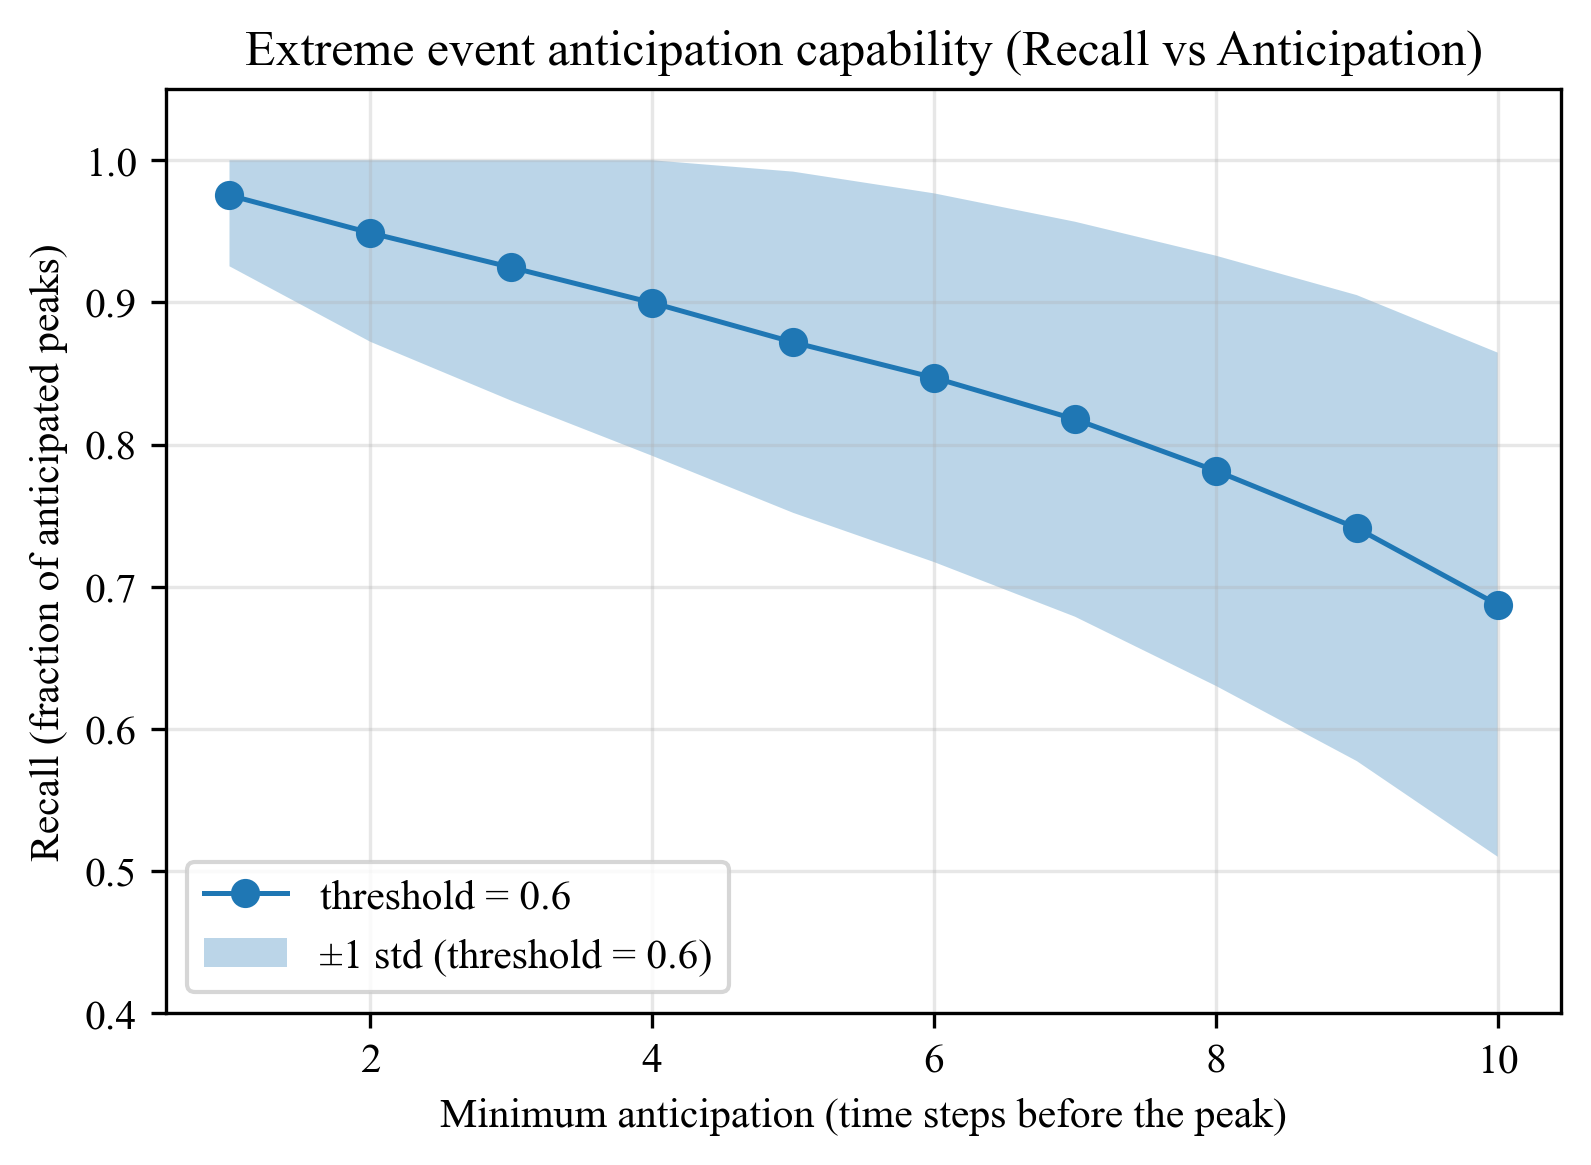

In [17]:
test_series = generate_multiple_series(
    length=config["p_model"]["series_length"],
    p_value=config["p_model"]["p_value"],
    num_series=config["data"]["num_series_test"],
    peak_percentile=config["data"]["peak_percentile"],
)

all_metrics = []
all_recalls = []

indices = np.linspace(0, len(test_series) - 1, 500, dtype=int)

for count, i in enumerate(indices):
    df = test_series[i]

    print(
        f"\n Synthetic series {count + 1}/{len(indices)} "
        f"(index {i})"
    )

    metrics, ks, recalls = evaluate_and_plot_streaming(
        model,
        df,
        device,
        lookahead=config["data"]["lookahead"],
        plot=False,
        title="P-model time series with extreme event labels and LSTM prediction"
    )

    print(metrics)

    all_metrics.append(metrics)
    all_recalls.append(recalls)


# ---------- Aggregate recalls ----------
all_recalls = np.array(all_recalls)  

mean_recall = np.nanmean(all_recalls, axis=0)
std_recall = np.nanstd(all_recalls, axis=0)

# Clip to valid recall range
lower = np.clip(mean_recall - std_recall, 0, 1)
upper = np.clip(mean_recall + std_recall, 0, 1)

# ---------- Recall vs Anticipation Plot ----------
plt.figure(figsize=(6, 4))

plt.plot(
    ks,
    mean_recall,
    marker="o",
    markersize=6,
    linewidth=1.2,
    label="threshold = 0.6"
)

plt.fill_between(
    ks,
    lower,
    upper,
    alpha=0.3,
    label="±1 std (threshold = 0.6)"
)

plt.xlabel("Minimum anticipation (time steps before the peak)")
plt.ylabel("Recall (fraction of anticipated peaks)")
plt.title("Extreme event anticipation capability (Recall vs Anticipation)")
plt.grid(alpha=0.3)
plt.legend()
plt.ylim(0.4, 1.05)

plt.show()



(0.45, 1.05)

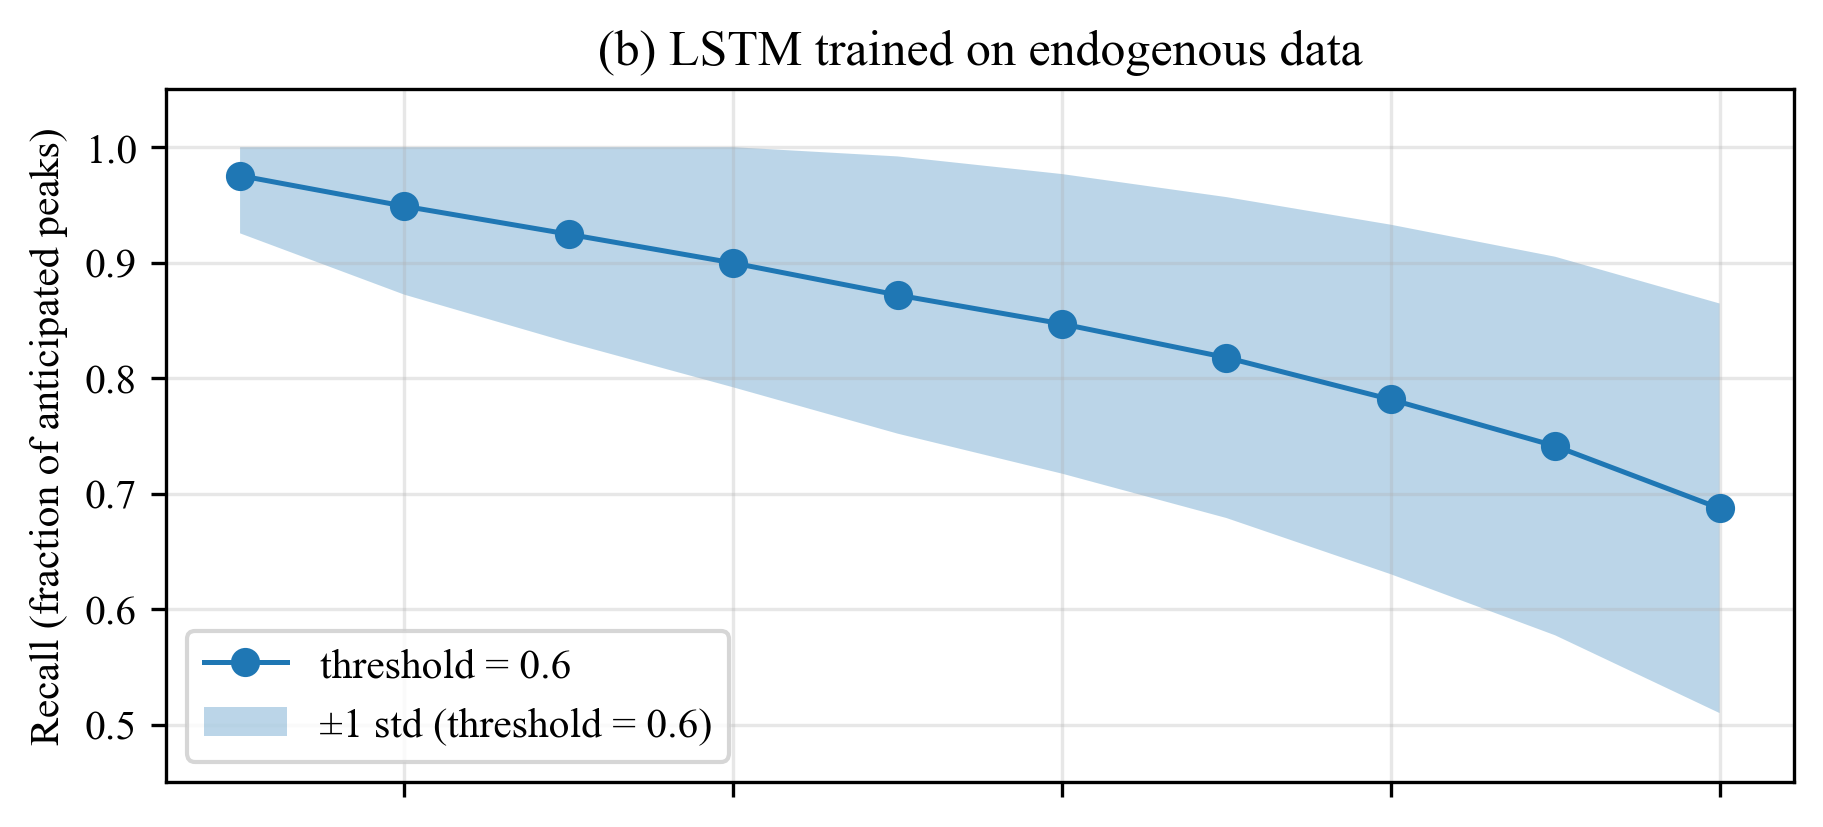

In [18]:
plt.figure(figsize=(7, 3))

plt.plot(
    ks,
    mean_recall,
    marker="o",
    markersize=6,
    linewidth=1.2,
    label="threshold = 0.6"
)

plt.fill_between(
    ks,
    lower,
    upper,
    alpha=0.3,
    label="±1 std (threshold = 0.6)"
)

plt.ylabel("Recall (fraction of anticipated peaks)")
plt.title(
    "(b) LSTM trained on endogenous data"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tick_params(axis='x', labelbottom=False)
plt.ylim(0.45, 1.05)

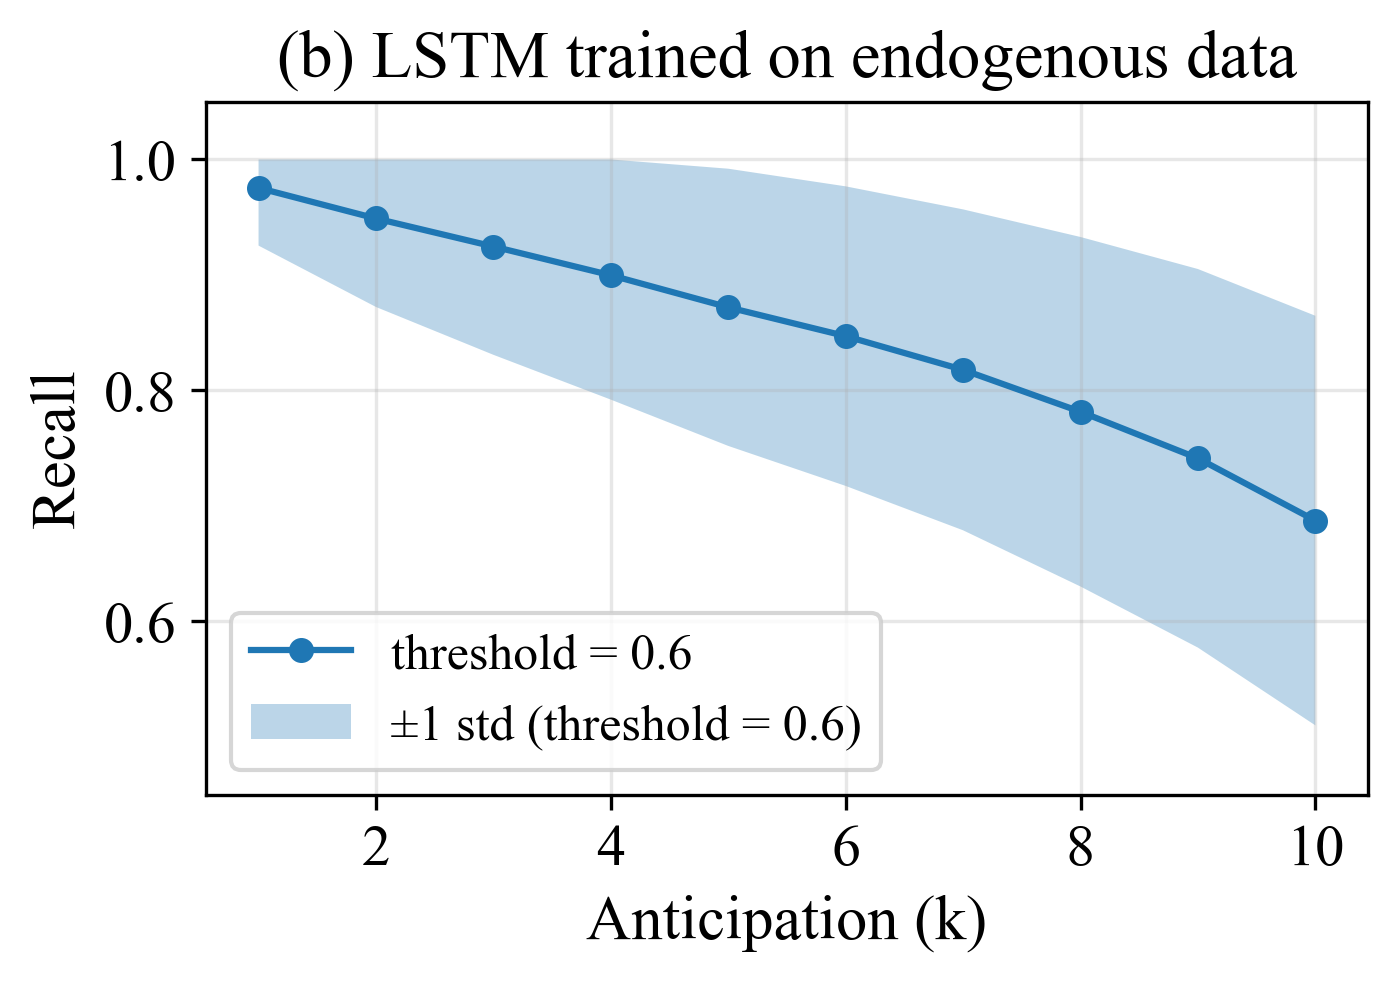

In [23]:
plt.figure(figsize=(5, 3))

plt.plot(
    ks,
    mean_recall,
    marker="o",
    markersize=5,
    label="threshold = 0.6"
)

plt.fill_between(
    ks,
    lower,
    upper,
    alpha=0.3,
    label="±1 std (threshold = 0.6)"
)

plt.ylabel("Recall")
plt.title(
    "(b) LSTM trained on endogenous data"
)
plt.grid(alpha=0.3)
plt.legend()
plt.xlabel("Anticipation (k)")
# plt.tick_params(axis='x', labelbottom=False)
plt.ylim(0.45, 1.05)


plt.savefig("../paper/images/recall_vs_anticipation_endogenous_data_h.png", dpi=300, bbox_inches='tight')  

plt.show()

In [7]:

test_series = generate_multiple_series(
    length=config["p_model"]["series_length"],
    p_value=[0.18, 0.42],
    num_series=config["data"]["num_series_test"],
    peak_percentile=config["data"]["peak_percentile"],
)

all_metrics = []
all_recalls = []

indices = np.linspace(0, len(test_series) - 1, 500, dtype=int)

for count, i in enumerate(indices):
    df = test_series[i]

    print(
        f"\n Synthetic series {count + 1}/{len(indices)} "
        f"(index {i})"
    )

    metrics, ks, recalls = evaluate_and_plot_streaming(
        model,
        df,
        device,
        lookahead=config["data"]["lookahead"],
        plot=False,
        title="P-model time series with extreme event labels and LSTM prediction"
    )

    print(metrics)

    all_metrics.append(metrics)
    all_recalls.append(recalls)


# ---------- Aggregate recalls ----------
all_recalls = np.array(all_recalls)  

mean_recall = np.nanmean(all_recalls, axis=0)
std_recall = np.nanstd(all_recalls, axis=0)

# Clip to valid recall range
lower = np.clip(mean_recall - std_recall, 0, 1)
upper = np.clip(mean_recall + std_recall, 0, 1)



[0.18, 0.42]

 Synthetic series 1/500 (index 0)
{'AUC-PR': 0.32180555859568366, 'Precision': 0.5, 'Recall': 0.0759493670886076, 'F1': 0.13186813186813187, 'P-value': np.float64(0.18)}

 Synthetic series 2/500 (index 3)
{'AUC-PR': 0.26879031221047595, 'Precision': 0.6, 'Recall': 0.09230769230769231, 'F1': 0.16, 'P-value': np.float64(0.18)}

 Synthetic series 3/500 (index 6)
{'AUC-PR': 0.28022292319575787, 'Precision': 0.5454545454545454, 'Recall': 0.08695652173913043, 'F1': 0.15, 'P-value': np.float64(0.18)}

 Synthetic series 4/500 (index 9)
{'AUC-PR': 0.31256871758148663, 'Precision': 0.4117647058823529, 'Recall': 0.10294117647058823, 'F1': 0.16470588235294117, 'P-value': np.float64(0.18)}

 Synthetic series 5/500 (index 12)
{'AUC-PR': 0.6375966905549832, 'Precision': 0.9166666666666666, 'Recall': 0.1774193548387097, 'F1': 0.2972972972972973, 'P-value': np.float64(0.18)}

 Synthetic series 6/500 (index 15)
{'AUC-PR': 0.15857102799755465, 'Precision': 0.16071428571428573, 'Recall': 0.2

KeyboardInterrupt: 

In [ ]:
all_metrics = pd.DataFrame(all_metrics)
all_metrics['P-value'] = all_metrics['P-value'].astype(float).round(2)

table = (
    all_metrics
    .groupby('P-value', as_index=False)
    .mean()
)

def highlight_best_worst(s):
    is_max = s == s.max()
    is_min = s == s.min()
    
    styles = []
    for max_v, min_v in zip(is_max, is_min):
        if max_v:
            styles.append('background-color: #b7f7c1; font-weight: bold')  # best (green)
        elif min_v:
            styles.append('background-color: #f7b7b7; font-weight: bold')  # worst (red)
        else:
            styles.append('')
    
    return styles

styled_table = (
    table
    .style
    .apply(highlight_best_worst, axis=0)  
    .format("{:.3f}")
)

styled_table

,P-value,AUC-PR,Precision,Recall,F1
0,0.180,0.336,0.583,0.131,0.201
1,0.190,0.268,0.370,0.104,0.161
2,0.200,0.257,0.356,0.114,0.153
3,0.210,0.293,0.353,0.153,0.209
4,0.220,0.266,0.343,0.144,0.190
5,0.230,0.237,0.263,0.156,0.193
6,0.240,0.289,0.339,0.254,0.264
7,0.250,0.259,0.252,0.255,0.240
8,0.260,0.314,0.316,0.390,0.333
9,0.270,0.387,0.308,0.368,0.326


In [ ]:
all_metrics = pd.DataFrame(all_metrics)
all_metrics['P-value'] = all_metrics['P-value'].astype(float).round(2)

# métricas (exclui P-value)
metrics_cols = all_metrics.columns.drop('P-value')

# agrupa por p para evitar repetição
table = (
    all_metrics
    .groupby('P-value', as_index=False)[metrics_cols]
    .mean()
)

# média global das métricas
table['Média'] = table[metrics_cols].mean(axis=1)

def highlight_best_worst(s):
    is_max = s == s.max()
    is_min = s == s.min()
    
    return [
        'background-color: #b7f7c1; font-weight: bold' if max_v
        else 'background-color: #f7b7b7; font-weight: bold' if min_v
        else ''
        for max_v, min_v in zip(is_max, is_min)
    ]

styled_table = (
    table
    .style
    .apply(highlight_best_worst, axis=0)
    .format({c: "{:.3f}" for c in metrics_cols})
)

styled_table


,P-value,AUC-PR,Precision,Recall,F1,Média
0,0.180000,0.336,0.583,0.131,0.201,0.312563
1,0.190000,0.268,0.370,0.104,0.161,0.225680
2,0.200000,0.257,0.356,0.114,0.153,0.219983
3,0.210000,0.293,0.353,0.153,0.209,0.251894
4,0.220000,0.266,0.343,0.144,0.190,0.236051
5,0.230000,0.237,0.263,0.156,0.193,0.212369
6,0.240000,0.289,0.339,0.254,0.264,0.286802
7,0.250000,0.259,0.252,0.255,0.240,0.251461
8,0.260000,0.314,0.316,0.390,0.333,0.338028
9,0.270000,0.387,0.308,0.368,0.326,0.347341


In [ ]:
# Split by P-value ranges
exogenous = all_metrics[(all_metrics['P-value'] >= 0.18) & (all_metrics['P-value'] <= 0.28)]
transition = all_metrics[(all_metrics['P-value'] > 0.28) & (all_metrics['P-value'] < 0.32)]
endogenous = all_metrics[(all_metrics['P-value'] >= 0.32) & (all_metrics['P-value'] <= 0.42)]
mixed = all_metrics  

# Compute means
table = pd.DataFrame({
    'Exogenous': exogenous.mean(),
    'Transition': transition.mean(),
    'Endogenous': endogenous.mean(),
    'Mixed': mixed.mean()
}).T

# Drop P-value column (not meaningful to average)
table = table.drop(columns=['P-value'])

# Style table
styled_table = (
    table
    .style
    .apply(highlight_best_worst, axis=0)
    .format("{:.3f}")
)

table.to_csv("../paper/metrics_by_regime_endogenous.csv", float_format="%.3f")

styled_table


,AUC-PR,Precision,Recall,F1
Exogenous,0.311,0.349,0.240,0.249
Transition,0.679,0.534,0.636,0.551
Endogenous,0.778,0.546,0.797,0.628
Mixed,0.561,0.458,0.533,0.452


[0.38, 0.38]


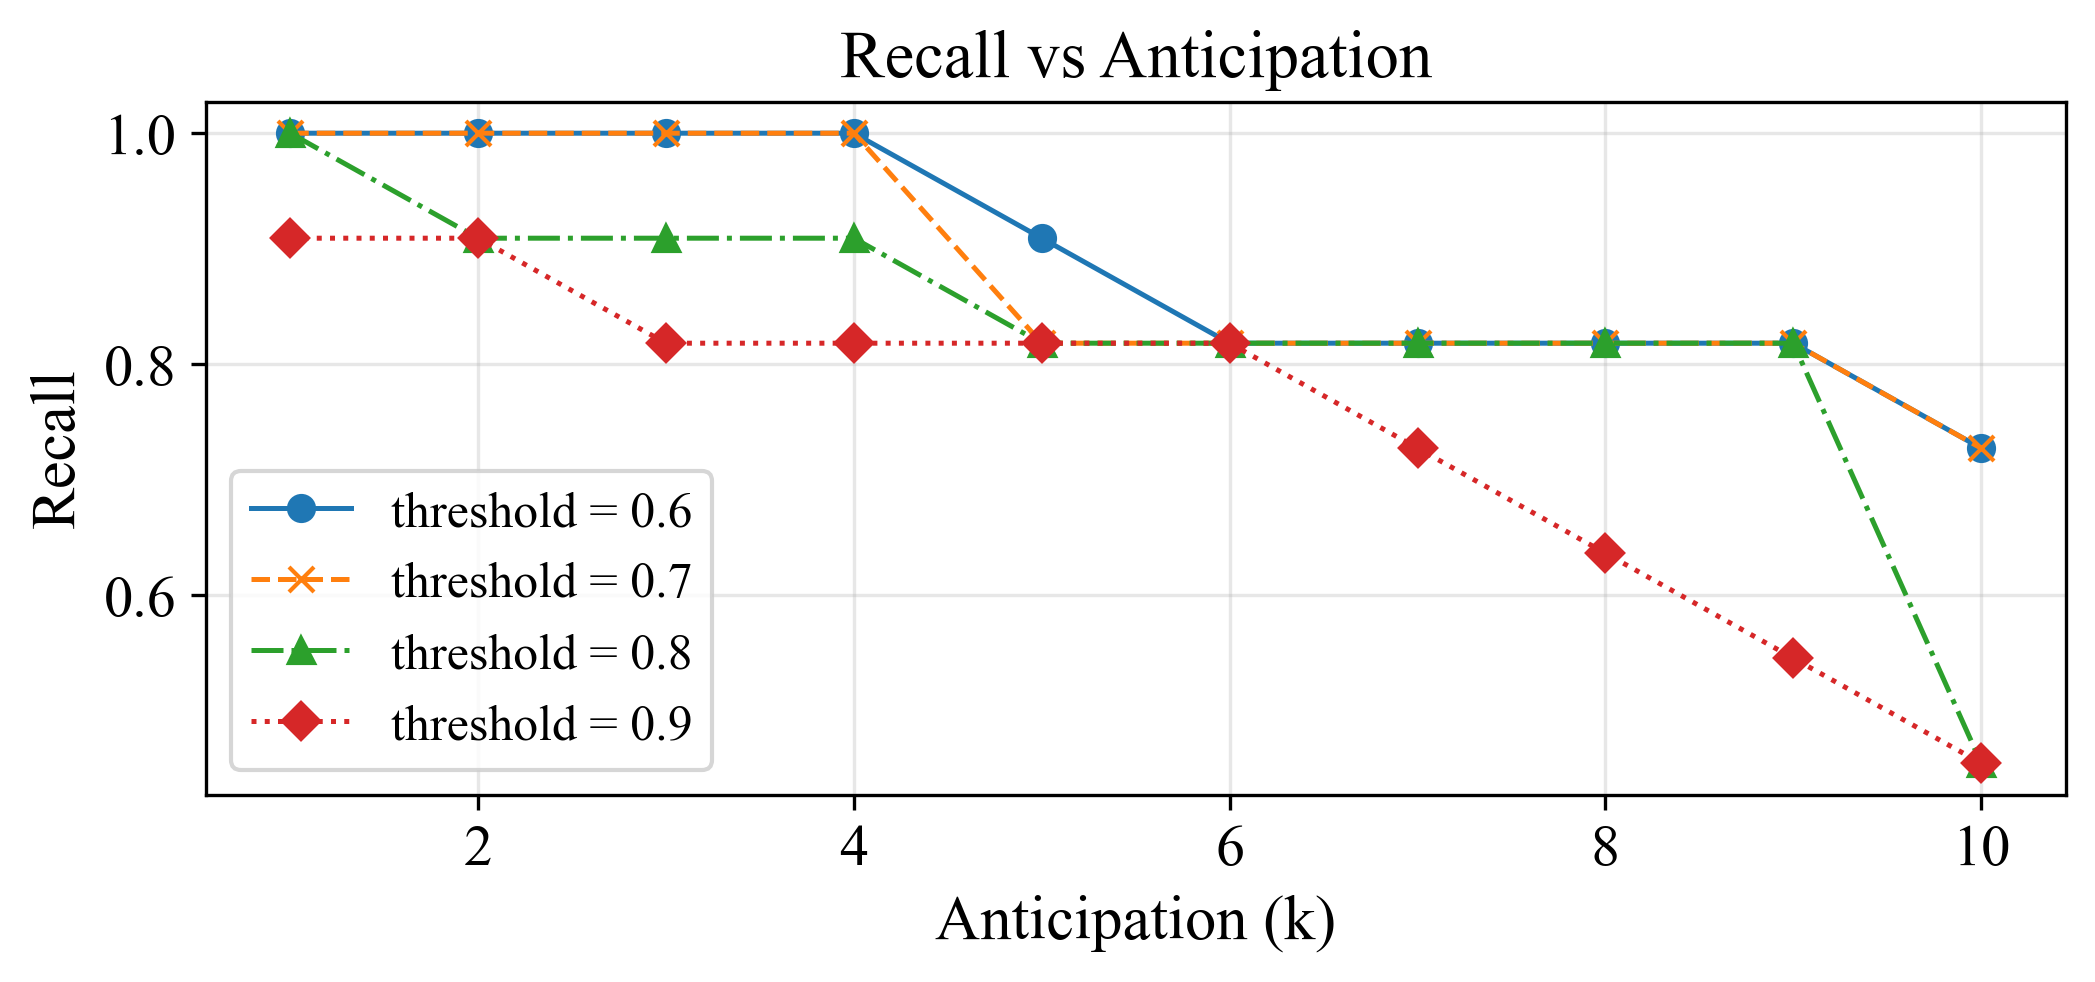

/var/folders/25/4ts88tzd08500lbfck1y7nn40000gn/T/ipykernel_46626/1846533069.py:353: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


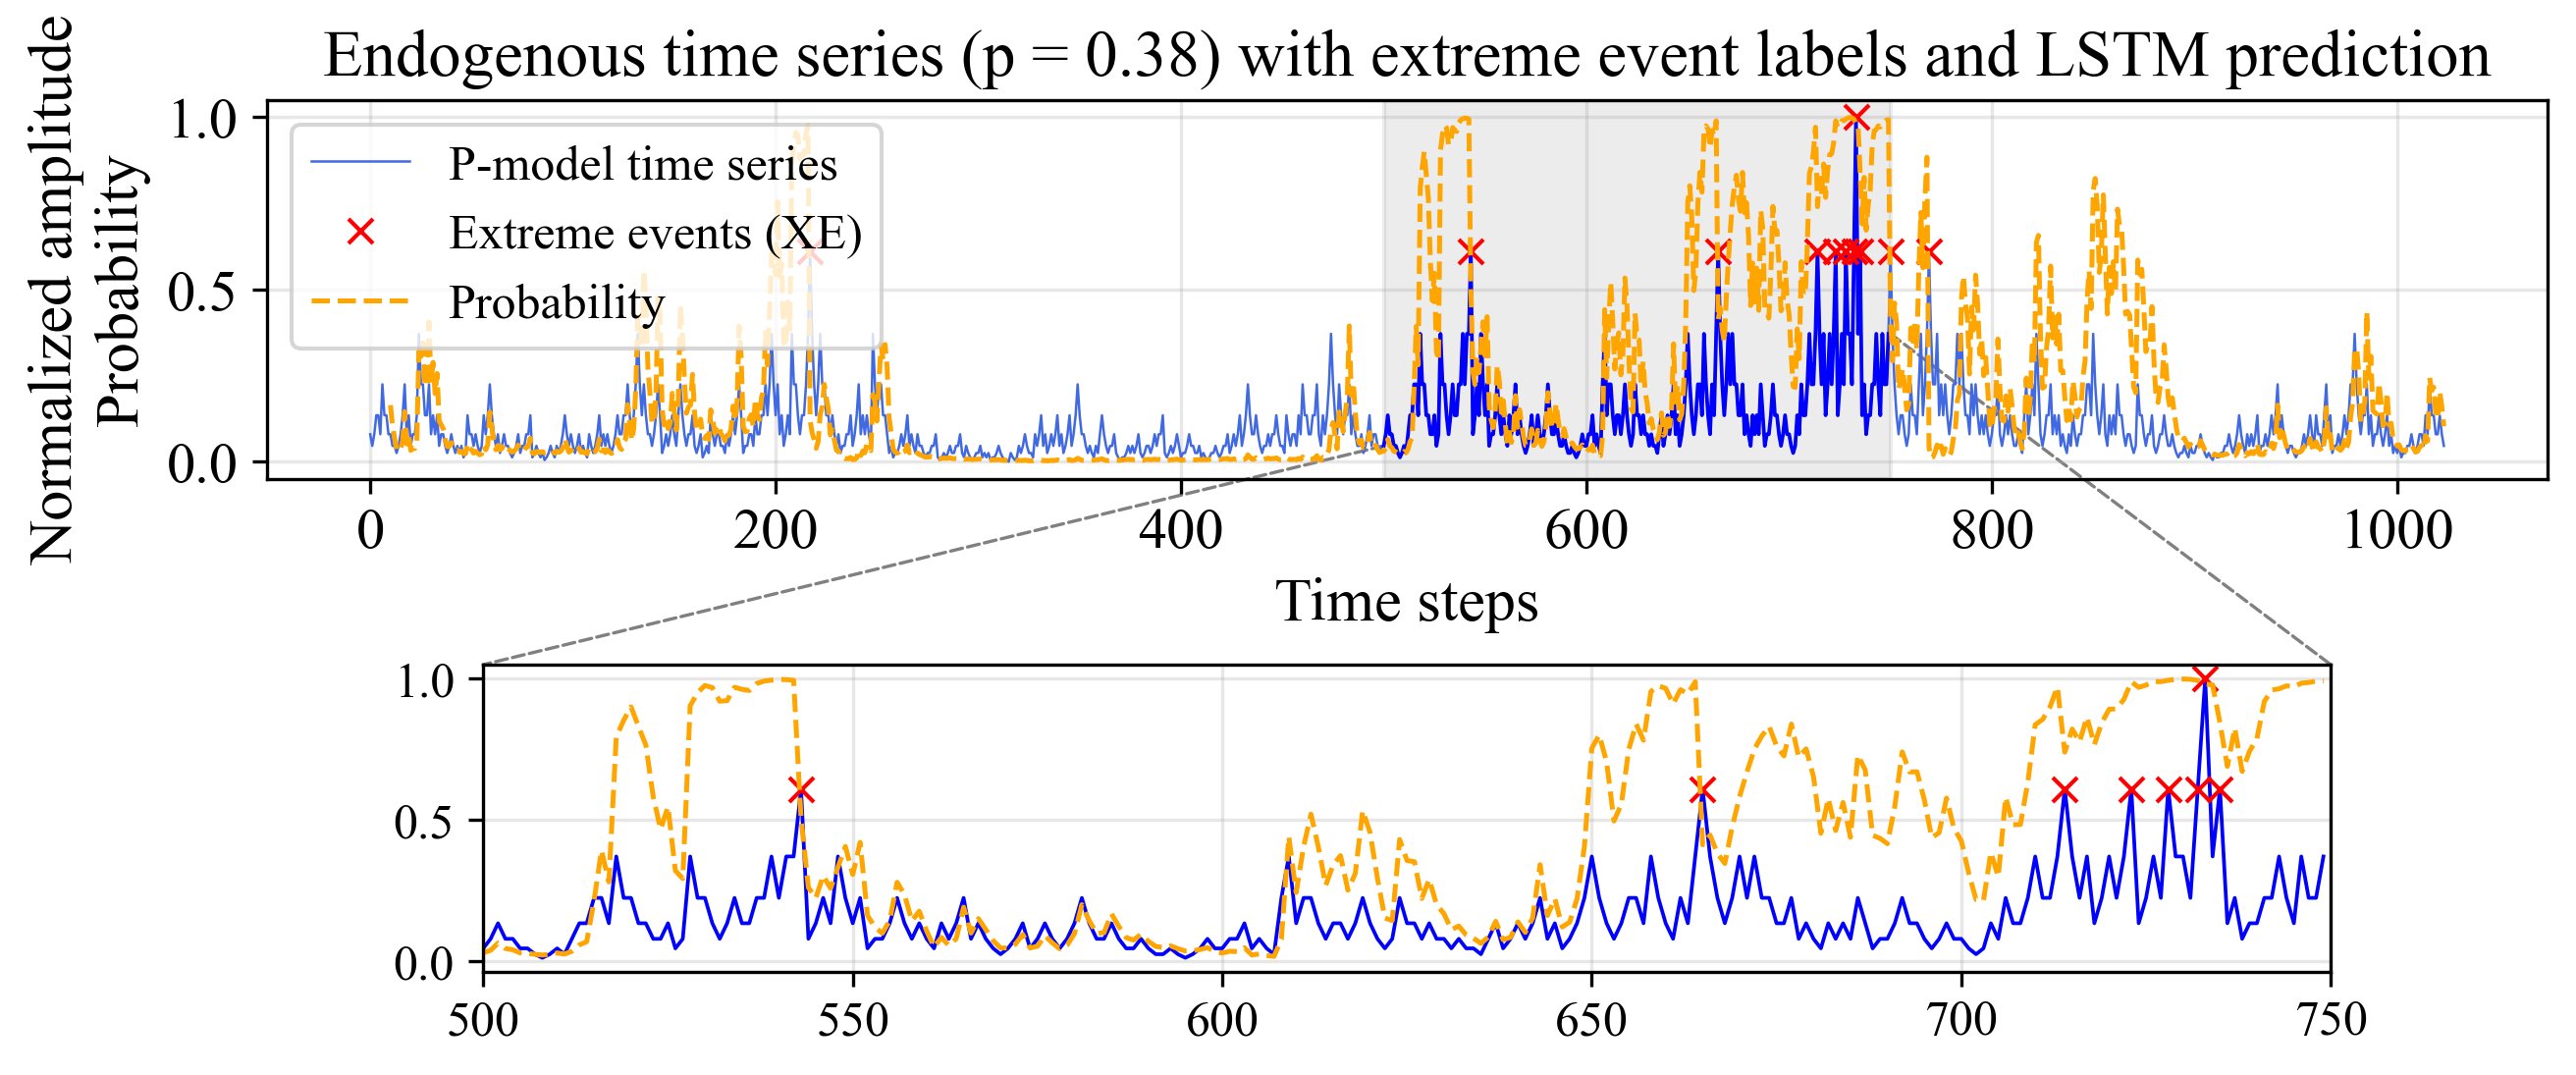

{'AUC-PR': 0.8406210586781212, 'Precision': 0.5964912280701754, 'Recall': 0.8395061728395061, 'F1': 0.6974358974358974, 'P-value': np.float64(0.38)}


In [25]:
np.random.seed(26)

test_series = generate_multiple_series(
    length=config["p_model"]["series_length"],
    p_value=[0.38, 0.38],
    num_series=3,
    peak_percentile=config["data"]["peak_percentile"],
)

all_metrics = []
all_recalls = []

df = test_series[1]

metrics, ks, recalls = evaluate_and_plot_streaming(
    model,
    df,
    device,
    lookahead=config["data"]["lookahead"],
    plot=True,
    box_cut=(500, 750),
    title="Endogenous time series (p = 0.38) with extreme event labels and LSTM prediction",
    path_ra = "../paper/images/endogenous_time_series_(p_=_0.38)_recall_vs_anticipacion.png",
    path_series = "../paper/images/endogenous_time_series_(p_=_0.38)_with_extreme_event_labels_and_lstm_prediction.png"
)

print(metrics)

all_metrics.append(metrics)
all_recalls.append(recalls)

